In [8]:
# IMPORTANT: RUN THIS CELL IN ORDER TO IMPORT YOUR KAGGLE DATA SOURCES,
# THEN FEEL FREE TO DELETE THIS CELL.
# NOTE: THIS NOTEBOOK ENVIRONMENT DIFFERS FROM KAGGLE'S PYTHON
# ENVIRONMENT SO THERE MAY BE MISSING LIBRARIES USED BY YOUR
# NOTEBOOK.
import kagglehub
harishthakur995_global_spice_consumption_path = kagglehub.dataset_download('harishthakur995/global-spice-consumption')

print('Data source import complete.')


Data source import complete.


In [9]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All"
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/global-spice-consumption/Export.csv


  Domain Code                        Domain  Area Code (M49)         Area  \
0         TCL  Crops and livestock products                4  Afghanistan   
1         TCL  Crops and livestock products                4  Afghanistan   
2         TCL  Crops and livestock products                4  Afghanistan   
3         TCL  Crops and livestock products                4  Afghanistan   
4         TCL  Crops and livestock products                4  Afghanistan   

   Element Code  Item Code (CPC)  \
0          5610             1654   
1          5610             1654   
2          5610             1654   
3          5610             1654   
4          5610             1654   

                                                Item  Year Unit   Import  \
0  Anise, badian, coriander, cumin, caraway, fenn...  2014    t   283.85   
1  Anise, badian, coriander, cumin, caraway, fenn...  2015    t  1000.16   
2  Anise, badian, coriander, cumin, caraway, fenn...  2016    t   814.88   
3  Anise, badian

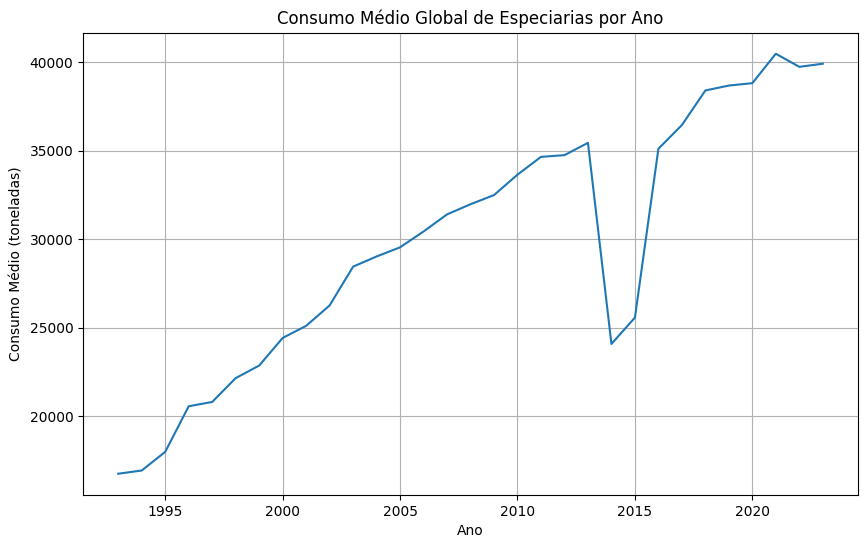

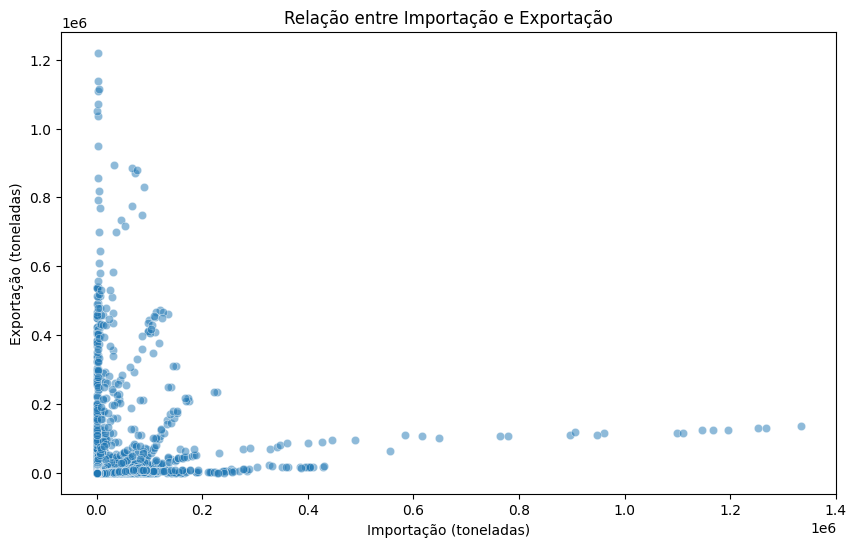

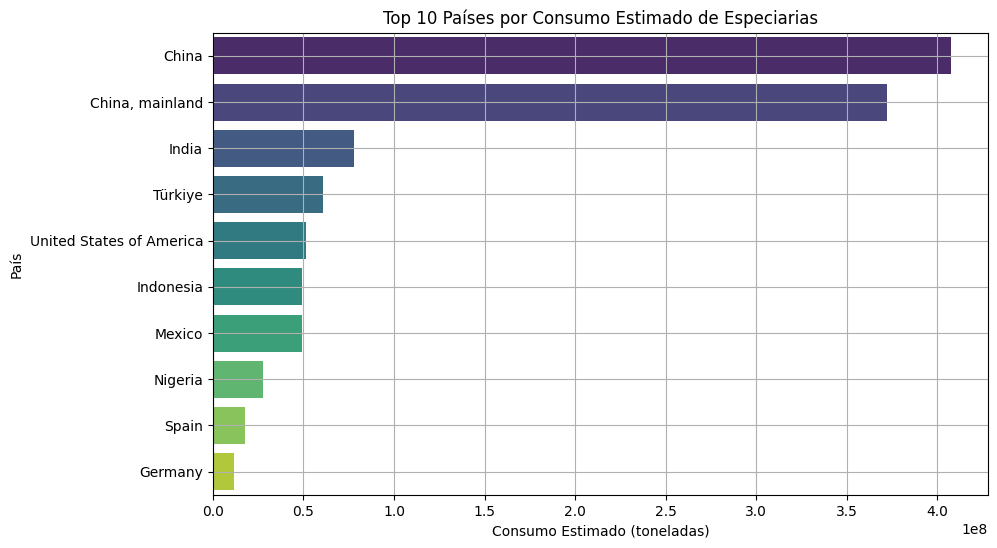

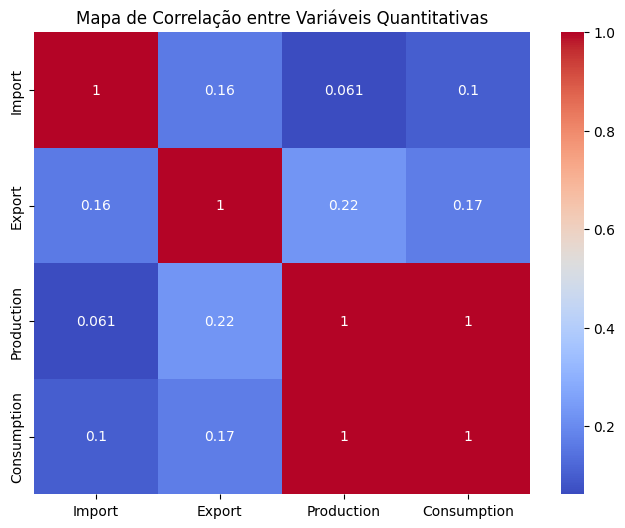

In [13]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Carregando o dataset
df = pd.read_csv('/kaggle/input/global-spice-consumption/Export.csv')

# Visualização inicial
print(df.head())
print(df.info())
print(df.describe())
print(df.isnull().sum())

# ------------------------
# VISUALIZAÇÕES RELEVANTES
# ------------------------

# Gráfico: evolução do consumo ao longo dos anos (média global)
plt.figure(figsize=(10,6))
consumo_por_ano = df.groupby('Year')['Consumption'].mean()
sns.lineplot(x=consumo_por_ano.index, y=consumo_por_ano.values)
plt.title('Consumo Médio Global de Especiarias por Ano')
plt.xlabel('Ano')
plt.ylabel('Consumo Médio (toneladas)')
plt.grid(True)
plt.show()

# Corrigindo possíveis espaços nos nomes das colunas
df.columns = df.columns.str.strip()

# Gráfico: comparação entre Importação e Exportação
plt.figure(figsize=(10,6))
sns.scatterplot(data=df, x='Import', y='Export', alpha=0.5)
plt.title('Relação entre Importação e Exportação')
plt.xlabel('Importação (toneladas)')
plt.ylabel('Exportação (toneladas)')
plt.show()


# Gráfico: países com maior produção média
top_consumo = df.groupby('Area')['Consumption'].sum().sort_values(ascending=False).head(10)
plt.figure(figsize=(10,6))
sns.barplot(
    x=top_consumo.values,
    y=top_consumo.index,
    hue=top_consumo.index,    # Usa o índice como hue pra aplicar a paleta
    dodge=False,              # Evita deslocamento das barras
    palette='viridis',
    legend=False              # Remove a legenda redundante
)
plt.title('Top 10 Países por Consumo Estimado de Especiarias')
plt.xlabel('Consumo Estimado (toneladas)')
plt.ylabel('País')
plt.grid(True)
plt.show()


# Heatmap de correlação
plt.figure(figsize=(8,6))
sns.heatmap(df[['Import', 'Export', 'Production', 'Consumption']].corr(), annot=True, cmap='coolwarm')
plt.title('Mapa de Correlação entre Variáveis Quantitativas')
plt.show()
